# Metocean and field development with NeqSim

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/metocean_and_field_development.ipynb)

This advanced case turns a public historical wind-and-wave time series into seasonal
operability, extreme-value, joint-environment, and process-design inputs. It then uses
NeqSim to quantify how seawater temperature changes a subsea tie-back screening result.

**Learning outcomes**

1. Select Python packages for metocean acquisition, statistics, spectra, tides, and loads.
2. Preserve data provenance and distinguish hindcast history from design criteria.
3. Calculate monthly statistics, joint seas, weather windows, and return levels.
4. Translate environmental cases into NeqSim boundary conditions.
5. Connect operability and process impacts to schedule and field-development choices.

## Decision question and safe interpretation

**Question:** How do environmental seasonality, marine-operability limits, and subsea
thermal response affect the preferred installation season and tie-back design basis?

The source is the public `NORA_test.txt` example distributed by `MET-OM/metocean-stats`.
It is a historical NORA10 teaching dataset with anonymized coordinates, not a site-specific
certified metocean basis. A compact, checksum-controlled copy is kept beside this notebook.
No result here should be used as a design extreme, vessel guarantee, or operational limit.

For an operation requiring $N$ consecutive samples within limits, the empirical start
probability in month $m$ is

$$p_m=\frac{1}{n_m}\sum_{t\in m}\mathbf{1}\!\left(\bigcap_{k=0}^{N-1}X_{t+k}\right)$$

where $X$ is true when all wind-and-wave criteria pass.

## Package map

| Task | Packages demonstrated | Useful extensions |
|---|---|---|
| Hindcast/API acquisition | `metocean-api` | `copernicusmarine`, `cdsapi` |
| Labelled arrays and files | `xarray`, `pandas` | `dask`, `netCDF4`, `zarr` |
| Standard metocean reports | `metocean-stats` | `windrose`, `seaborn` |
| Wave spectra | `wavespectra` | `xarray-simlab` workflows |
| Univariate extremes | `pyextremes`, `scipy` | threshold/storm declustering studies |
| Joint environmental contours | `virocon` | model-selection and bootstrap studies |
| Tidal harmonic analysis | `UTide` | `pytmd`, local observations |
| Mooring/wave modelling | — | `MoorPy`, `dnora`, SWAN/WW3 |
| Process and flow assurance | NeqSim bridge + current Java `master` | transient and segmented models |

`MoorPy` and `dnora` are highlighted as downstream extensions rather than forced into the
core runtime: mooring or wave-model configuration should follow the concept selected.

In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys

PYTHON_NEQSIM_VERSION = "3.16.0"
NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")

try:
    installed_bridge_version = version("neqsim")
except PackageNotFoundError:
    installed_bridge_version = None
if installed_bridge_version != PYTHON_NEQSIM_VERSION:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            f"neqsim=={PYTHON_NEQSIM_VERSION}",
        ],
        check=True,
    )

using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ
if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import jpype

if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )
jpype.addClassPath(str(SOURCE_JAR))
from neqsim.neqsimpython import init_jvm

init_jvm()
SOURCE_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Loaded Java classes from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")

NeqSim Python bridge: 3.16.0
NeqSim source ref: master
NeqSim source commit: 9e8d44a141bba600026d2229969b49af50f34237
NeqSim source JAR SHA-256: 4f65f4a3018c8d4f10b84c367c906de212c52b3dbd7b133f0887550df5d9552e
Loaded Java classes from: file:/workspace/scratch/6302cef4de4f/neqsim-java-master/target/neqsim-3.16.0.jar
Python runtime: 3.12.13


In [2]:
from importlib.metadata import version
from pathlib import Path
import contextlib
import hashlib
import os
import sys
import urllib.request
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as scipy_stats
import xarray as xr
from IPython.display import display

# Some restricted PID namespaces hide the current process from psutil. Dask, which is
# imported by wavespectra and metocean-api, can safely fall back to os.sched_getaffinity.
if not Path(f"/proc/{os.getpid()}").exists():
    sys.modules["psutil"] = None

from metocean_api.ts import TimeSeries
from metocean_stats.tables import (
    scatter_diagram,
    table_monthly_non_exceedance,
    table_monthly_weather_window,
)
from pyextremes import EVA
from utide import reconstruct, solve
from virocon import (
    GlobalHierarchicalModel,
    IFORMContour,
    get_DNVGL_Hs_Tz,
)
from wavespectra.construct import frequency

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.style.use("seaborn-v0_8-whitegrid")

used_packages = [
    "metocean-api",
    "metocean-stats",
    "xarray",
    "wavespectra",
    "pyextremes",
    "virocon",
    "utide",
]
display(pd.DataFrame(
    {"package": used_packages, "version": [version(name) for name in used_packages]}
))

,package,version
0,metocean-api,1.1.14
1,metocean-stats,1.2.0
2,xarray,2026.7.0
3,wavespectra,4.8.0
4,pyextremes,2.5.0
5,virocon,2.4.0
6,utide,0.3.1


## 1. Load an immutable public-data snapshot

The snapshot contains 3-hourly values from 1958–1979 and seven selected columns. Its
upstream raw file is pinned to commit
`6077d6b256f7574b009778246d90c74bb67915e9` in `MET-OM/metocean-stats`.
When opened directly in Colab, the cell downloads the repository copy. Both the upstream
and compact-file hashes are printed so the executed artifact records its exact evidence.

In [3]:
SNAPSHOT_NAME = "nora10_metocean_stats_1958_1979.csv.gz"
SNAPSHOT_PATHS = [
    Path("notebooks/fielddevelopment/data") / SNAPSHOT_NAME,
    Path("data") / SNAPSHOT_NAME,
    Path(SNAPSHOT_NAME),
]
SNAPSHOT_URL = (
    "https://raw.githubusercontent.com/EvenSol/NeqSim-Colab/master/"
    "notebooks/fielddevelopment/data/" + SNAPSHOT_NAME
)
EXPECTED_SNAPSHOT_SHA256 = "cb6b0585dadcf4c668b421bd994b275a0eb096af99ae2caad269c3039e5818e2"
UPSTREAM_RAW_SHA256 = "14f184062645314b1b3465eba7d64d3f5cc6da0dd583ae723687aad6dc4e9f7e"

snapshot_path = next((path for path in SNAPSHOT_PATHS if path.exists()), None)
if snapshot_path is None:
    snapshot_path = Path("/tmp") / SNAPSHOT_NAME
    urllib.request.urlretrieve(SNAPSHOT_URL, snapshot_path)

actual_snapshot_hash = hashlib.sha256(snapshot_path.read_bytes()).hexdigest()
assert actual_snapshot_hash == EXPECTED_SNAPSHOT_SHA256
metocean = pd.read_csv(snapshot_path, parse_dates=["time"]).set_index("time")
metocean = metocean.rename(columns={
    "air_temperature_C": "t2m",
    "wind_speed_10m_m_s": "w10",
    "wind_direction_deg": "wind_dir",
    "significant_wave_height_m": "hs",
    "peak_period_s": "tp",
    "mean_wave_direction_deg": "wave_dir",
})

print("Snapshot SHA-256:", actual_snapshot_hash)
print("Upstream raw SHA-256:", UPSTREAM_RAW_SHA256)
print("Coverage:", metocean.index.min(), "to", metocean.index.max())
print("Rows:", f"{len(metocean):,}", "| nominal time step: 3 hours")
display(metocean.head())

assert metocean.index.is_monotonic_increasing
assert not metocean.index.has_duplicates
assert metocean[["hs", "tp", "w10"]].notna().all().all()
assert (metocean[["hs", "tp", "w10"]] >= 0.0).all().all()

Snapshot SHA-256: cb6b0585dadcf4c668b421bd994b275a0eb096af99ae2caad269c3039e5818e2
Upstream raw SHA-256: 14f184062645314b1b3465eba7d64d3f5cc6da0dd583ae723687aad6dc4e9f7e
Coverage: 1958-01-01 00:00:00 to 1979-12-31 21:00:00
Rows: 64,280 | nominal time step: 3 hours


,t2m,w10,wind_dir,hs,tp,wave_dir
time,,,,,,
1958-01-01 00:00:00,3.0,4.9,349.0,1.9,9.2,330.0
1958-01-01 03:00:00,2.4,5.5,358.0,1.8,9.2,337.0
1958-01-01 06:00:00,3.3,7.1,360.0,1.9,9.2,342.0
1958-01-01 09:00:00,2.7,6.3,5.0,1.9,9.2,346.0
1958-01-01 12:00:00,2.9,5.9,12.0,1.8,9.2,348.0


## Optional NORA3 refresh with `metocean-api`

`metocean-api` exposes NORA3 wind, wave, wind-wave, spectra, storm-surge, and offshore-wind
products through a common `TimeSeries` interface. The guarded example requests one month
and is deliberately off by default. Follow the service documentation, cache downloads,
avoid parallel NORA3 requests, and record the exact product, point, variables, timestamps,
and package version.

In [4]:
ENABLE_LIVE_NORA3 = False
if ENABLE_LIVE_NORA3:
    live_request = TimeSeries(
        lon=2.55,
        lat=60.55,
        start_time="2025-01-01T00:00",
        end_time="2025-01-31T21:00",
        variable=["hs", "tp"],
        product="NORA3_wave_sub",
        name="FieldDevelopmentTeachingPoint",
    )
    live_request.load_data()
    print("Live NORA3 request completed; inspect and persist its metadata before use.")
else:
    print("Live NORA3 refresh disabled; using the immutable teaching snapshot.")

Live NORA3 refresh disabled; using the immutable teaching snapshot.


## 2. Represent the time series with `xarray`

`xarray` keeps variable names, units, time coordinates, and aggregation logic together.
This is especially valuable when the same workflow moves from a single point to a gridded
hindcast. Monthly averages show seasonality but do not define environmental extremes.

,t2m,w10,hs,tp
month,,,,
1,4.76,10.15,3.12,9.96
2,4.31,9.24,2.75,9.80
3,4.80,9.20,2.65,9.58
4,5.90,7.86,2.07,8.84
5,7.99,6.99,1.64,8.08
6,10.72,6.83,1.48,7.59
7,12.24,6.86,1.44,7.32
8,13.10,6.55,1.40,7.52
9,11.66,8.19,2.04,8.37


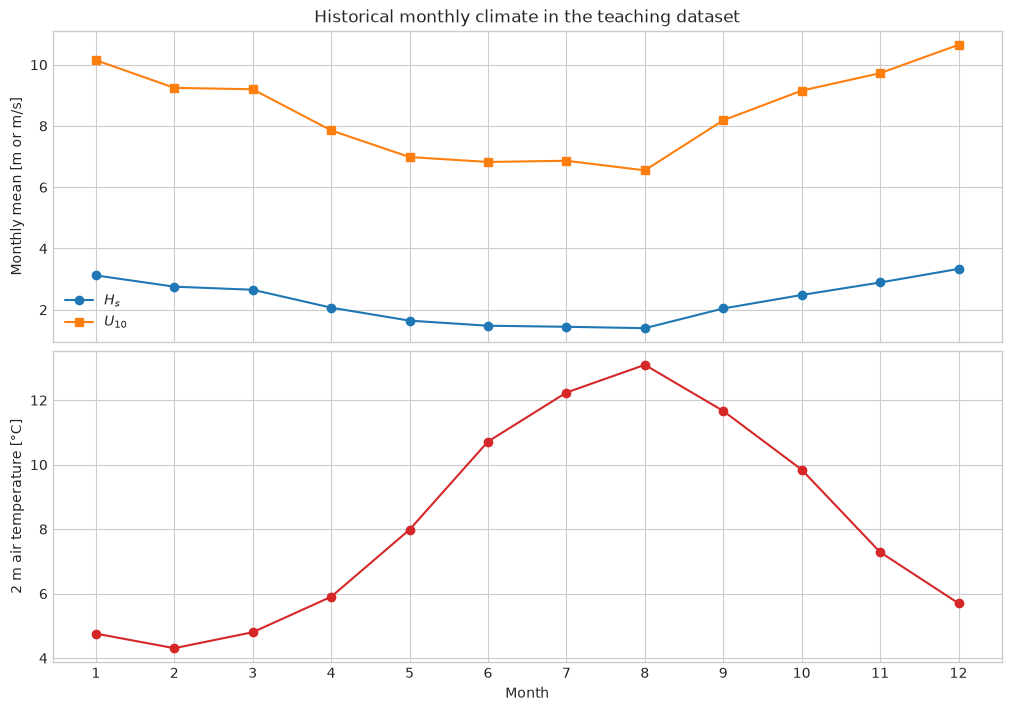

In [5]:
metocean_ds = xr.Dataset.from_dataframe(metocean[["t2m", "w10", "hs", "tp"]])
metocean_ds["t2m"].attrs = {"long_name": "2 m air temperature", "units": "degC"}
metocean_ds["w10"].attrs = {"long_name": "10 m wind speed", "units": "m s-1"}
metocean_ds["hs"].attrs = {"long_name": "significant wave height", "units": "m"}
metocean_ds["tp"].attrs = {"long_name": "peak wave period", "units": "s"}

monthly_climate = metocean_ds.groupby("time.month").mean()
display(monthly_climate.to_dataframe().round(2))

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
axes[0].plot(monthly_climate.month, monthly_climate.hs, marker="o", label="$H_s$")
axes[0].plot(monthly_climate.month, monthly_climate.w10, marker="s", label="$U_{10}$")
axes[0].set_ylabel("Monthly mean [m or m/s]")
axes[0].set_title("Historical monthly climate in the teaching dataset")
axes[0].legend()
axes[1].plot(monthly_climate.month, monthly_climate.t2m, marker="o", color="tab:red")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("2 m air temperature [°C]")
axes[1].set_xticks(np.arange(1, 13))
plt.show()

## 3. Standard tables with `metocean-stats`

The package supplies repeatable non-exceedance, scatter, joint-distribution, extreme, and
weather-window reporting. Here we create a monthly wave-height non-exceedance table and a
joint $H_s$–$T_p$ occurrence table. Generated CSV is sent to `/tmp`; the notebook retains
the returned DataFrames as its auditable result.

In [6]:
non_exceedance = table_monthly_non_exceedance(
    metocean,
    var="hs",
    step_var=1.0,
    output_file="/tmp/hs_monthly_non_exceedance.csv",
)
joint_occurrence = scatter_diagram(
    metocean,
    var1="hs",
    step_var1=0.5,
    var2="tp",
    step_var2=1.0,
    number_of_events=False,
    output_file="/tmp/hs_tp_scatter.csv",
)
display(non_exceedance.loc[["<1.0", "<2.0", "<3.0", "<4.0"]].round(1))
display(joint_occurrence.iloc[:8, :10].round(2))

level_rows = [label for label in non_exceedance.index if str(label).startswith("<")]
assert 99.0 <= float(non_exceedance.loc[level_rows[-1], "Year"]) <= 100.0
assert joint_occurrence.shape[0] > 5 and joint_occurrence.shape[1] > 5

time,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,Year
hs-level,,,,,,,,,,,,,
<1.0,4.0,7.9,9.5,18.0,30.1,37.9,35.6,37.2,18.5,8.4,5.0,3.0,17.9
<2.0,28.2,37.6,40.0,60.4,74.1,79.6,81.8,84.6,59.9,45.6,29.1,24.5,53.8
<3.0,55.2,66.3,68.0,82.0,91.2,94.2,96.2,96.4,83.8,74.1,62.6,50.8,76.7
<4.0,76.4,82.7,84.2,92.8,97.4,98.7,99.5,99.3,93.7,88.4,82.4,71.5,88.9


,2-3 | 0.00%,3-4 | 0.34%,4-5 | 2.31%,5-6 | 7.88%,6-7 | 17.29%,7-8 | 12.08%,8-9 | 13.33%,9-10 | 13.55%,10-11 | 11.87%,11-12 | 9.30%
13.0-13.5 | 0.00%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12.5-13.0 | 0.00%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12.0-12.5 | 0.00%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11.5-12.0 | 0.00%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11.0-11.5 | 0.00%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10.5-11.0 | 0.01%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10.0-10.5 | 0.01%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
09.5-10.0 | 0.03%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Weather-window and waiting-time screen

The illustrative vessel limit is $H_s\leq2.5$ m and $U_{10}\leq12$ m/s for 24 consecutive
hours (eight 3-hourly samples). We calculate both valid-start probability and the empirical
wait from every timestamp to the next valid start. A project should add direction, current,
visibility, vessel-response criteria, forecast uncertainty, mobilisation rules, and data
gaps.

In [7]:
operation_hours = 24
samples_per_operation = operation_hours // 3
within_limits = (metocean["hs"] <= 2.5) & (metocean["w10"] <= 12.0)
valid_start = (
    within_limits.iloc[::-1]
    .rolling(samples_per_operation, min_periods=samples_per_operation)
    .sum()
    .iloc[::-1]
    .eq(samples_per_operation)
)

start_positions = np.flatnonzero(valid_start.to_numpy())
all_positions = np.arange(len(valid_start))
next_indices = np.searchsorted(start_positions, all_positions, side="left")
waiting_steps = np.full(len(valid_start), np.nan)
has_future_window = next_indices < len(start_positions)
waiting_steps[has_future_window] = (
    start_positions[next_indices[has_future_window]] - all_positions[has_future_window]
)

operability = pd.DataFrame({
    "valid_start": valid_start,
    "waiting_days": waiting_steps * 3.0 / 24.0,
})
monthly_operability = operability.groupby(operability.index.month).agg(
    valid_start_probability=("valid_start", "mean"),
    mean_wait_days=("waiting_days", "mean"),
    p90_wait_days=("waiting_days", lambda values: values.quantile(0.90)),
)
monthly_operability.index.name = "month"
display(monthly_operability.round(3))

with contextlib.chdir("/tmp"):
    package_weather_window = table_monthly_weather_window(
        metocean,
        var=["hs", "w10"],
        threshold=[2.5, 12.0],
        window_size=operation_hours,
        timestep=3,
        output_file="/tmp/monthly_weather_window.csv",
    )
display(package_weather_window.round(2))

assert monthly_operability["valid_start_probability"].between(0.0, 1.0).all()
assert monthly_operability["mean_wait_days"].notna().all()

,valid_start_probability,mean_wait_days,p90_wait_days
month,,,
1,0.243,3.933,10.625
2,0.349,3.241,7.375
3,0.364,2.624,7.750
4,0.543,0.928,3.125
5,0.708,0.499,1.875
6,0.738,0.390,1.500
7,0.790,0.277,1.125
8,0.801,0.246,1.000
9,0.547,1.339,4.500


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Mean,5.3,4.6,4.0,2.0,1.5,1.4,1.3,1.3,2.4,4.1,5.6,7.3
P10,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
P50,3.6,2.4,2.2,1.0,1.0,1.0,1.0,1.0,1.0,1.9,3.5,4.8
P90,12.2,9.9,9.8,4.4,3.0,2.5,2.2,2.1,5.5,9.6,13.1,18.2
P95,15.2,16.2,14.0,5.8,4.0,3.4,3.0,2.8,7.9,13.4,18.1,22.1
Max,27.6,41.0,26.2,9.8,11.5,10.4,5.8,6.1,15.4,40.8,44.9,41.9


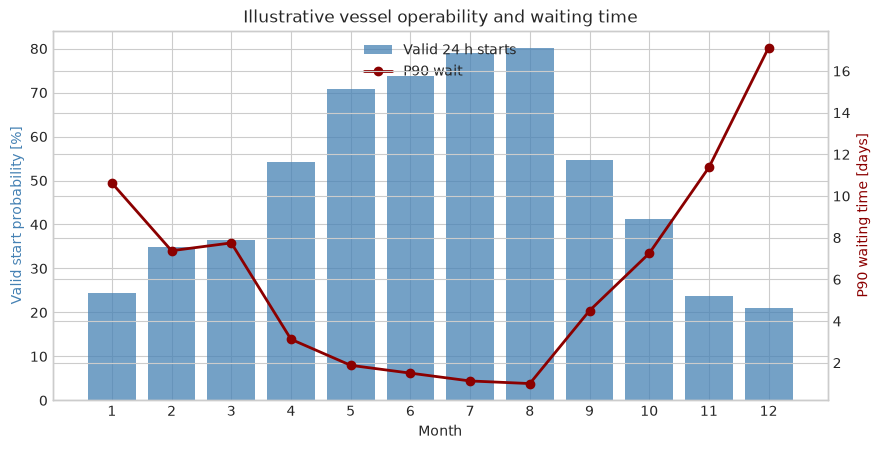

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 4.8))
ax2 = ax1.twinx()
ax1.bar(
    monthly_operability.index,
    100.0 * monthly_operability["valid_start_probability"],
    color="steelblue",
    alpha=0.75,
    label="Valid 24 h starts",
)
ax2.plot(
    monthly_operability.index,
    monthly_operability["p90_wait_days"],
    color="darkred",
    marker="o",
    linewidth=2,
    label="P90 wait",
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Valid start probability [%]", color="steelblue")
ax2.set_ylabel("P90 waiting time [days]", color="darkred")
ax1.set_xticks(np.arange(1, 13))
ax1.set_title("Illustrative vessel operability and waiting time")
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper center")
plt.show()

## 5. Univariate extremes with `pyextremes`

Annual block maxima are fit with a generalized extreme-value distribution. `pyextremes`
provides the engineering workflow; an independent SciPy fit is used as a numerical cross-
check. With only 22 years and anonymized location, the 50-year estimate is deliberately
shown as an extrapolation example, not a design value.

For annual exceedance probability $p=1/T_R$, the return level is

$$z_{T_R}=G^{-1}\!\left(1-\frac{1}{T_R}\right)$$

where $G$ is the fitted annual-maximum distribution.

In [9]:
wave_eva = EVA(metocean["hs"])
wave_eva.get_extremes(
    method="BM",
    extremes_type="high",
    block_size="365.2425D",
    errors="ignore",
)
wave_eva.fit_model(model="MLE", distribution="genextreme")

return_periods = np.array([10.0, 25.0, 50.0])
pyextremes_levels = np.array([
    wave_eva.get_return_value(
        return_period=period,
        return_period_size="365.2425D",
        alpha=None,
    )[0]
    for period in return_periods
])

annual_maxima = metocean["hs"].resample("YE").max().dropna()
shape, location, scale = scipy_stats.genextreme.fit(annual_maxima)
scipy_levels = scipy_stats.genextreme.ppf(
    1.0 - 1.0 / return_periods,
    shape,
    loc=location,
    scale=scale,
)
extreme_table = pd.DataFrame({
    "return_period_years": return_periods,
    "pyextremes_Hs_m": pyextremes_levels,
    "scipy_cross_check_Hs_m": scipy_levels,
})
extreme_table["absolute_difference_m"] = (
    extreme_table["pyextremes_Hs_m"]
    - extreme_table["scipy_cross_check_Hs_m"]
).abs()
display(extreme_table.round(3))

assert len(annual_maxima) >= 20
assert (extreme_table["absolute_difference_m"] < 0.05).all()
assert np.diff(pyextremes_levels).min() > 0.0

,return_period_years,pyextremes_Hs_m,scipy_cross_check_Hs_m,absolute_difference_m
0,10.0,11.155,11.161,0.005
1,25.0,12.058,12.057,0.001
2,50.0,12.769,12.760,0.009


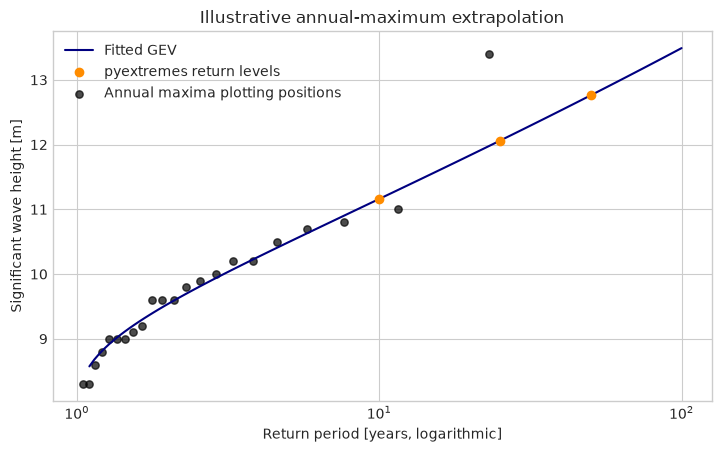

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot_periods = np.geomspace(1.1, 100.0, 120)
plot_levels = scipy_stats.genextreme.ppf(
    1.0 - 1.0 / plot_periods,
    shape,
    loc=location,
    scale=scale,
)
ax.semilogx(plot_periods, plot_levels, color="navy", label="Fitted GEV")
ax.scatter(return_periods, pyextremes_levels, color="darkorange", zorder=3,
           label="pyextremes return levels")
ax.scatter(
    (len(annual_maxima) + 1.0) / np.arange(1, len(annual_maxima) + 1),
    np.sort(annual_maxima)[::-1],
    color="black",
    s=28,
    alpha=0.7,
    label="Annual maxima plotting positions",
)
ax.set_xlabel("Return period [years, logarithmic]")
ax.set_ylabel("Significant wave height [m]")
ax.set_title("Illustrative annual-maximum extrapolation")
ax.legend()
plt.show()

## 6. Joint sea states with `virocon`

The DNV-style predefined model in `virocon` uses $H_s$ and zero-up-crossing period $T_z$.
The teaching file contains peak period, so we apply the explicit screening conversion
$T_z=0.78T_p$. That conversion must be validated or replaced when measured spectra are
available. The IFORM contour uses a nominal 50-year, 3-hour sea-state exceedance
probability.

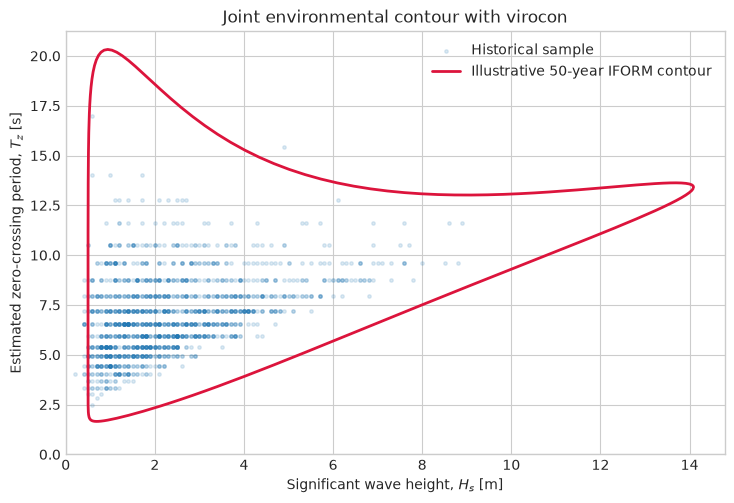

In [11]:
tz = 0.78 * metocean["tp"].to_numpy()
joint_data = np.column_stack([metocean["hs"].to_numpy(), tz])
dist_descriptions, fit_descriptions, semantics = get_DNVGL_Hs_Tz()
joint_model = GlobalHierarchicalModel(dist_descriptions)
joint_model.fit(joint_data, fit_descriptions=fit_descriptions)

sea_states_per_year = 365.25 * 8.0
contour_alpha = 1.0 / (50.0 * sea_states_per_year)
iform = IFORMContour(joint_model, alpha=contour_alpha, n_points=180)
contour_hs = iform.coordinates[:, 0]
contour_tz = iform.coordinates[:, 1]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sample = metocean.iloc[::40]
ax.scatter(sample["hs"], 0.78 * sample["tp"], s=6, alpha=0.15,
           label="Historical sample")
ax.plot(contour_hs, contour_tz, color="crimson", linewidth=2,
        label="Illustrative 50-year IFORM contour")
ax.set_xlim(left=0.0)
ax.set_ylim(bottom=0.0)
ax.set_xlabel("Significant wave height, $H_s$ [m]")
ax.set_ylabel("Estimated zero-crossing period, $T_z$ [s]")
ax.set_title("Joint environmental contour with virocon")
ax.legend()
plt.show()

assert contour_hs.max() > metocean["hs"].quantile(0.99)
assert np.isfinite(iform.coordinates).all()

## 7. A design sea-state spectrum with `wavespectra`

We select the contour point with maximum $H_s$ and approximate $T_p=T_z/0.78$. The
JONSWAP spectrum is scaled by `wavespectra` so integration recovers the requested
significant wave height. This is a spectral illustration, not a response-amplitude or
fatigue calculation.

Recovered spectral Hs: 14.089 m


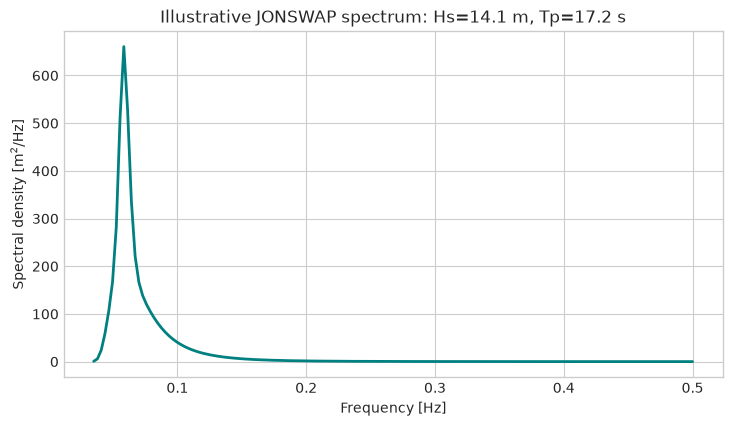

In [12]:
design_index = int(np.argmax(contour_hs))
design_hs = float(contour_hs[design_index])
design_tp = float(contour_tz[design_index] / 0.78)
frequency_grid = np.linspace(0.035, 0.50, 160)
design_spectrum = frequency.jonswap(
    freq=frequency_grid,
    fp=1.0 / design_tp,
    hs=design_hs,
    gamma=3.3,
)
recovered_hs = float(design_spectrum.spec.hs())

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(design_spectrum.freq, design_spectrum, color="teal", linewidth=2)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"Spectral density [m$^2$/Hz]")
ax.set_title(
    f"Illustrative JONSWAP spectrum: Hs={design_hs:.1f} m, Tp={design_tp:.1f} s"
)
plt.show()

print("Recovered spectral Hs:", f"{recovered_hs:.3f} m")
assert abs(recovered_hs - design_hs) < 0.02

## 8. Tidal harmonics with `UTide`

The source file has no sea level. To illustrate where tidal analysis fits, we generate a
90-day gauge-like teaching signal with known M2 and S2 constituents, fit it with `UTide`,
and reconstruct it. Replace this cell with quality-controlled local observations; do not
infer a site tide from this synthetic signal.

UTide reconstruction RMSE: 0.0151 m


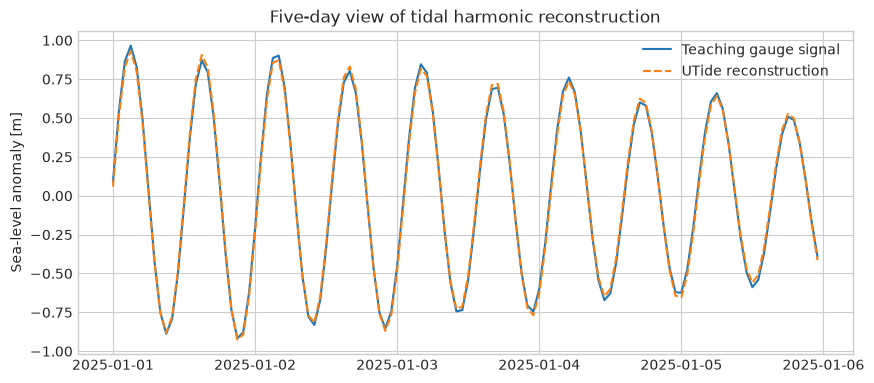

In [13]:
tide_time = pd.date_range("2025-01-01", periods=90 * 24, freq="h")
hours = np.arange(len(tide_time), dtype=float)
observed_tide = (
    0.72 * np.sin(2.0 * np.pi * hours / 12.4206)
    + 0.23 * np.sin(2.0 * np.pi * hours / 12.0 + 0.4)
    + 0.05 * np.sin(2.0 * np.pi * hours / 24.0)
)
tide_coefficients = solve(
    tide_time,
    observed_tide,
    lat=60.55,
    method="ols",
    conf_int="none",
    verbose=False,
)
reconstructed_tide = reconstruct(
    tide_time,
    tide_coefficients,
    verbose=False,
).h
tide_rmse = float(np.sqrt(np.mean((observed_tide - reconstructed_tide) ** 2)))

fig, ax = plt.subplots(figsize=(10, 4.2))
view = slice(0, 24 * 5)
ax.plot(tide_time[view], observed_tide[view], label="Teaching gauge signal")
ax.plot(tide_time[view], reconstructed_tide[view], linestyle="--",
        label="UTide reconstruction")
ax.set_ylabel("Sea-level anomaly [m]")
ax.set_title("Five-day view of tidal harmonic reconstruction")
ax.legend()
plt.show()

print("UTide reconstruction RMSE:", f"{tide_rmse:.4f} m")
assert tide_rmse < 0.08

## 9. Translate seawater cases into NeqSim boundaries

Seasonal air temperature is only a proxy in this anonymized dataset. For the screening
model we choose two explicit seabed-water cases, 4 °C and 10 °C, and hold flow, fluid,
geometry, roughness, insulation, inlet state, and model settings fixed. This isolates the
thermal boundary effect on a 70 km gas-condensate tie-back.

In [14]:
J = jpype.JClass
SystemSrkEos = J("neqsim.thermo.system.SystemSrkEos")
Stream = J("neqsim.process.equipment.stream.Stream")
PipeBeggsAndBrills = J("neqsim.process.equipment.pipeline.PipeBeggsAndBrills")


def make_field_fluid():
    fluid = SystemSrkEos(273.15 + 62.0, 165.0)
    for component, fraction in {
        "nitrogen": 0.012,
        "CO2": 0.020,
        "methane": 0.830,
        "ethane": 0.077,
        "propane": 0.037,
        "n-butane": 0.012,
        "n-pentane": 0.006,
        "n-hexane": 0.003,
        "water": 0.003,
    }.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid


def run_seawater_case(label, seawater_temperature_C):
    inlet = Stream(f"{label} inlet", make_field_fluid())
    inlet.setFlowRate(1.25, "MSm3/day")
    inlet.setPressure(165.0, "bara")
    inlet.setTemperature(62.0, "C")
    inlet.run()

    pipe = PipeBeggsAndBrills(f"{label} tie-back", inlet)
    pipe.setLength(70_000.0)
    pipe.setDiameter(0.3556)
    pipe.setPipeWallRoughness(4.5e-5)
    pipe.setElevation(-80.0)
    pipe.setNumberOfIncrements(70)
    pipe.setConstantSurfaceTemperature(seawater_temperature_C, "C")
    pipe.setHeatTransferCoefficient(2.2)
    pipe.run()
    outlet = pipe.getOutletStream()
    return {
        "case": label,
        "seawater_temperature_C": seawater_temperature_C,
        "arrival_temperature_C": outlet.getTemperature("C"),
        "arrival_pressure_bara": outlet.getPressure("bara"),
        "flow_MSm3_d": outlet.getFlowRate("MSm3/day"),
    }


process_cases = pd.DataFrame([
    run_seawater_case("cold season", 4.0),
    run_seawater_case("warm season", 10.0),
])
process_cases["arrival_pressure_margin_bar"] = (
    process_cases["arrival_pressure_bara"] - 70.0
)
display(process_cases.round(3))

assert (process_cases["arrival_pressure_margin_bar"] > 0.0).all()
assert (
    process_cases.loc[1, "arrival_temperature_C"]
    > process_cases.loc[0, "arrival_temperature_C"]
)
assert np.allclose(process_cases["flow_MSm3_d"], 1.25, rtol=1e-7)

,case,seawater_temperature_C,arrival_temperature_C,arrival_pressure_bara,flow_MSm3_d,arrival_pressure_margin_bar
0,cold season,4.0,5.307,165.328,1.25,95.328
1,warm season,10.0,11.107,165.221,1.25,95.221


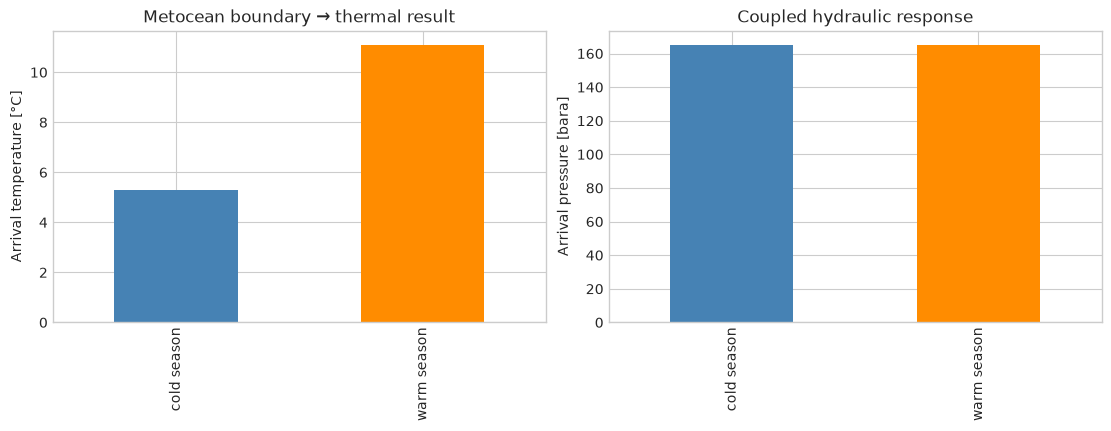

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
process_cases.plot.bar(
    x="case",
    y="arrival_temperature_C",
    color=["steelblue", "darkorange"],
    legend=False,
    ax=axes[0],
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Arrival temperature [°C]")
axes[0].set_title("Metocean boundary → thermal result")
process_cases.plot.bar(
    x="case",
    y="arrival_pressure_bara",
    color=["steelblue", "darkorange"],
    legend=False,
    ax=axes[1],
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Arrival pressure [bara]")
axes[1].set_title("Coupled hydraulic response")
plt.show()

## 10. Installation-season and cost screen

For a transparent commercial bridge, expected weather waiting days are multiplied by an
illustrative vessel spread rate. The month with the lowest mean wait is a statistical
screening candidate, not a scheduled campaign: mobilisation, daylight, ecology, competing
projects, forecast skill, port logistics, and serial operations can dominate.

In [16]:
vessel_spread_MUSD_per_day = 0.42
season_screen = monthly_operability.copy()
season_screen["expected_weather_cost_MUSD"] = (
    season_screen["mean_wait_days"] * vessel_spread_MUSD_per_day
)
season_screen["screen_rank"] = season_screen["expected_weather_cost_MUSD"].rank().astype(int)
display(season_screen.round(3).sort_values("screen_rank"))

preferred_month = int(season_screen["expected_weather_cost_MUSD"].idxmin())
print("Lowest historical mean-wait screening month:", preferred_month)
assert 1 <= preferred_month <= 12
assert (season_screen["expected_weather_cost_MUSD"] >= 0.0).all()

Lowest historical mean-wait screening month: 8


,valid_start_probability,mean_wait_days,p90_wait_days,expected_weather_cost_MUSD,screen_rank
month,,,,,
8,0.801,0.246,1.000,0.103,1
7,0.790,0.277,1.125,0.116,2
6,0.738,0.390,1.500,0.164,3
5,0.708,0.499,1.875,0.209,4
4,0.543,0.928,3.125,0.390,5
9,0.547,1.339,4.500,0.562,6
10,0.413,2.287,7.250,0.960,7
3,0.364,2.624,7.750,1.102,8
2,0.349,3.241,7.375,1.361,9


## Decision, limitations, and next work

The executed notebook identifies a season with the lowest historical mean weather wait,
quantifies the corresponding screening cost, produces univariate and joint environmental
illustrations, and shows the NeqSim arrival-temperature response to two seawater cases.
The value is the traceable boundary chain—not the anonymized numerical design values.

Before field-development use, acquire a site-specific hindcast and observations; quantify
bias, gaps, spatial resolution, non-stationarity, and storm independence; validate the
$T_p$/$T_z$ relationship; select extreme and contour models with uncertainty; incorporate
currents and directions; use vessel response/RAO limits; and connect observed seawater
profiles to segmented or transient NeqSim studies.

**Exercises**

1. Compare block-maxima and peaks-over-threshold return levels with storm declustering.
2. Add a second operation with a 72-hour duration and different wind/wave thresholds.
3. Sweep seawater temperature and heat-transfer coefficient in the NeqSim model.
4. Use `MoorPy` for a selected floating concept or `dnora` to configure a nested wave case.